In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
confusion_matrix, classification_report, RocCurveDisplay, ConfusionMatrixDisplay
)

In [ ]:
from google.colab import drive
drive.mount ('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
path = "/content/gdrive/MyDrive/MachineLearning/Praktikum4"

In [ ]:
import pandas as pd
df = pd.read_csv(path + '/Data/calonpembelimobil.csv')
df.head()

,ID,Usia,Status,Kelamin,Memiliki_Mobil,Penghasilan,Beli_Mobil
0,1,32,1,0,0,240,1
1,2,49,2,1,1,100,0
2,3,52,1,0,2,250,1
3,4,26,2,1,1,130,0
4,5,45,3,0,2,237,1


In [ ]:
X = df.drop(columns=["ID", "Beli_Mobil"])
y = df["Beli_Mobil"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Data latih:", X_train.shape)
print("Data uji:", X_test.shape)

Data latih: (800, 5)
Data uji: (200, 5)


In [ ]:
# Tentukan kolom numerik dan biner
feature_num = ["Usia", "Penghasilan"]
feature_bin = ["Status", "Kelamin", "Memiliki_Mobil"]

# Buat ColumnTransformer
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), feature_num),
        ('bin', 'passthrough', feature_bin)
    ],
    remainder='drop'
)

# Buat model Logistic Regression
model = LogisticRegression(max_iter=1000, solver='lbfgs', class_weight='balanced', random_state=42)

# Gabungkan ke pipeline
clf = Pipeline([
    ('preprocess', preprocess),
    ('model', model)
])

# Latih model
clf.fit(X_train, y_train)
print("✅ Model Logistic Regression berhasil dilatih.")

✅ Model Logistic Regression berhasil dilatih.



🎯 Akurasi: 0.91

📊 Classification Report:

               precision    recall  f1-score   support

           0       0.82      0.92      0.87        64
           1       0.96      0.90      0.93       136

    accuracy                           0.91       200
   macro avg       0.89      0.91      0.90       200
weighted avg       0.92      0.91      0.91       200



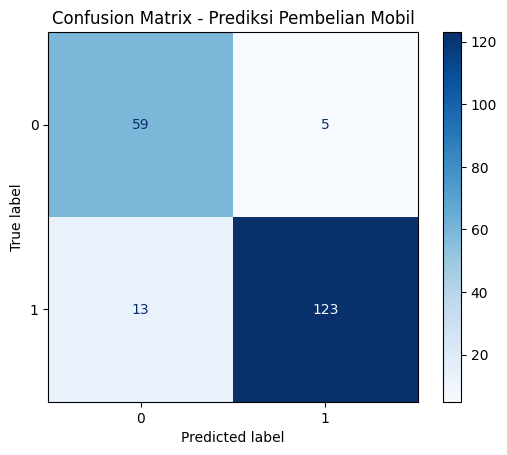

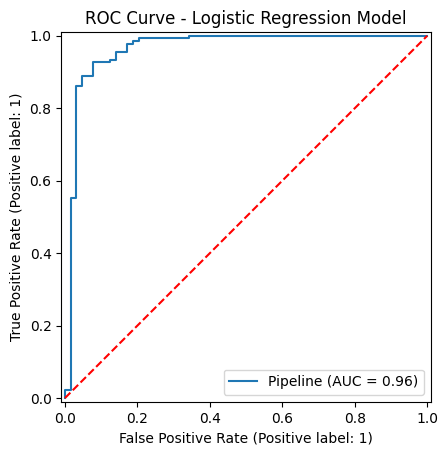

In [ ]:
# Prediksi pada dataset
y_pred = clf.predict(X_test)

# Akurasi
print("\n🎯 Akurasi:", accuracy_score(y_test, y_pred))

# Classification Report
print("\n📊 Classification Report:\n\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap= 'Blues')
plt.title("Confusion Matrix - Prediksi Pembelian Mobil")
plt.show()
print("=========================================================================")

#ROC Curve
RocCurveDisplay.from_estimator(clf, X_test, y_test)
plt.plot([0, 1], [0, 1], 'r--', label='Random Classifier')
plt.title("ROC Curve - Logistic Regression Model")
plt.show()

In [ ]:
# Contoh dataset baru
data_baru = pd.DataFrame({
    'Usia': [25, 45],
    'Status': [1, 3],
    'Kelamin': [1, 0],
    'Memiliki_Mobil': [0,1],
    'Penghasilan': [210, 250]
})

# Prediksi Kelas
prediksi = clf.predict(data_baru)
proba = clf.predict_proba(data_baru)

# Menampilkan Hasil
hasil = pd.DataFrame(data_baru)
hasil['Prediksi_BeliMobil'] = prediksi
hasil['Probabilitas_Beli(0=Tidak, 1=Ya)'] = proba[:,1]

print("\n🔍 Hasil Prediksi Dataset Baru:")
hasil


🔍 Hasil Prediksi Dataset Baru:


,Usia,Status,Kelamin,Memiliki_Mobil,Penghasilan,Prediksi_BeliMobil,"Probabilitas_Beli(0=Tidak, 1=Ya)"
0,25,1,1,0,210,0,0.186005
1,45,3,0,1,250,1,0.819549
